In [2]:
import os
import numpy as np
import librosa
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

# On définit le chemin une bonne fois pour toutes
DATA_PATH = '/kaggle/input/datasets/mymy026/sound-intention'

In [4]:
def process_audio(file_path, augment=False):
    y, sr = librosa.load(file_path, duration=3.0)
    if len(y) < sr * 3:
        y = np.pad(y, (0, int(sr * 3) - len(y)))
    
    if augment:
        y = librosa.effects.pitch_shift(y, sr=sr, n_steps=np.random.uniform(-2, 2))
    
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
    S_dB = librosa.power_to_db(S, ref=np.max)
    
    # On force la taille 128x128 pour le CNN
    if S_dB.shape[1] > 128: S_dB = S_dB[:, :128]
    else: S_dB = np.pad(S_dB, ((0,0), (0, 128 - S_dB.shape[1])))
    
    return (S_dB - S_dB.min()) / (S_dB.max() - S_dB.min() + 1e-6)

In [5]:
import matplotlib.pyplot as plt
import librosa.display

def plot_examples_per_class(X, y, label_encoder):
    unique_classes = np.unique(y)
    plt.figure(figsize=(20, 10))
    
    for i, class_idx in enumerate(unique_classes):
        # Trouver le premier exemple correspondant à cette classe
        idx = np.where(y == class_idx)[0][0]
        spec = X[idx].squeeze() # Enlever la dimension canal pour l'affichage
        
        plt.subplot(1, 4, i + 1)
        librosa.display.specshow(spec, x_axis='time', y_axis='mel', sr=22050)
        plt.colorbar(format='%+2.0f dB')
        plt.title(f"Classe : {label_encoder.inverse_transform([class_idx])[0]}")
    
    plt.tight_layout()
    plt.show()

# Appel de la fonction (utilise X_train et y_train créés précédemment)
plot_examples_per_class(X_train, y_train, le)

NameError: name 'X_train' is not defined

In [15]:
import os
import numpy as np

X, y_labels = [], []
classes = ['Cough', 'Estrus', 'Food', 'Normal']
TARGET_COUNT = 150  # On vise 150 échantillons par classe

print(f"Démarrage de la recherche dans : {DATA_PATH}")

for label in classes:
    files_found = []
    
    # On parcourt tout l'arbre des dossiers
    for root, dirs, files in os.walk(DATA_PATH):
        for f in files:
            if f.lower().endswith('.wav'):
                full_path = os.path.join(root, f)
                # On vérifie si le label est présent dans le chemin (dossier ou nom de fichier)
                if label.lower() in full_path.lower():
                    files_found.append(full_path)
    
    print(f"Classe {label} : {len(files_found)} fichiers réels trouvés.")
    
    if not files_found:
        print(f"⚠️ Alerte : Aucun fichier pour {label}. Vérifie l'orthographe du dossier.")
        continue
    
    # 1. Ajouter tous les originaux trouvés
    for f in files_found:
        spec = process_audio(f)
        if spec is not None:
            X.append(spec)
            y_labels.append(label)
    
    # 2. Appliquer l'augmentation UNIQUEMENT si nécessaire
    # On calcule combien il en manque pour atteindre TARGET_COUNT
    num_already_in_X = y_labels.count(label)
    
    # On n'augmente que 'Cough' et 'Normal' comme tu l'as suggéré
    if label in ['Cough', 'Normal'] and num_already_in_X < TARGET_COUNT:
        num_to_add = TARGET_COUNT - num_already_in_X
        print(f"   -> Augmentation : +{num_to_add} pour {label}")
        for _ in range(num_to_add):
            f = np.random.choice(files_found)
            spec = process_audio(f, augment=True)
            if spec is not None:
                X.append(spec)
                y_labels.append(label)
    else:
        print(f"   -> Pas d'augmentation pour {label} (suffisant ou non-minoritaire)")

# --- VÉRIFICATION FINALE ---
X = np.array(X)[..., np.newaxis]
le = LabelEncoder()
y_encoded = le.fit_transform(y_labels)

# On affiche le décompte final pour être sûr
from collections import Counter
print("\nRépartition finale des classes dans le dataset :")
print(Counter(y_labels))

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, stratify=y_encoded, random_state=42)
print(f"\n✅ Total : {len(X)} images prêtes pour l'entraînement.")

Démarrage de la recherche dans : /kaggle/input/datasets/mymy026/sound-intention
Classe Cough : 11 fichiers réels trouvés.
   -> Augmentation : +139 pour Cough
Classe Estrus : 117 fichiers réels trouvés.
   -> Pas d'augmentation pour Estrus (suffisant ou non-minoritaire)
Classe Food : 100 fichiers réels trouvés.
   -> Pas d'augmentation pour Food (suffisant ou non-minoritaire)
Classe Normal : 42 fichiers réels trouvés.
   -> Augmentation : +108 pour Normal

Répartition finale des classes dans le dataset :
Counter({'Cough': 150, 'Normal': 150, 'Estrus': 117, 'Food': 100})

✅ Total : 517 images prêtes pour l'entraînement.


In [16]:
model = models.Sequential([
    layers.Input(shape=(128, 128, 1)),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5), # Protection contre l'overfitting
    layers.Dense(len(classes), activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [17]:
# Ici, on utilise X_train qui a été défini en cellule 3
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=30,
    batch_size=32,
    callbacks=[callbacks.EarlyStopping(patience=5, restore_best_weights=True)]
)

Epoch 1/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 330ms/step - accuracy: 0.2996 - loss: 1.4946 - val_accuracy: 0.7115 - val_loss: 0.7922
Epoch 2/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 327ms/step - accuracy: 0.6644 - loss: 0.7984 - val_accuracy: 0.7788 - val_loss: 0.5502
Epoch 3/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 312ms/step - accuracy: 0.7487 - loss: 0.6238 - val_accuracy: 0.8077 - val_loss: 0.4776
Epoch 4/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 310ms/step - accuracy: 0.7630 - loss: 0.5864 - val_accuracy: 0.7981 - val_loss: 0.4097
Epoch 5/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 322ms/step - accuracy: 0.7603 - loss: 0.5639 - val_accuracy: 0.8269 - val_loss: 0.4135
Epoch 6/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 319ms/step - accuracy: 0.8079 - loss: 0.4827 - val_accuracy: 0.8558 - val_loss: 0.3736
Epoch 7/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 322ms/step - accuracy: 0.7449 - loss: 0.5874 - val_accuracy: 0.8654 - val_loss: 0.3752
Epoch 8/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 321ms/step - accuracy: 0.8276 - loss: 0.4593 - val_accuracy: 0.

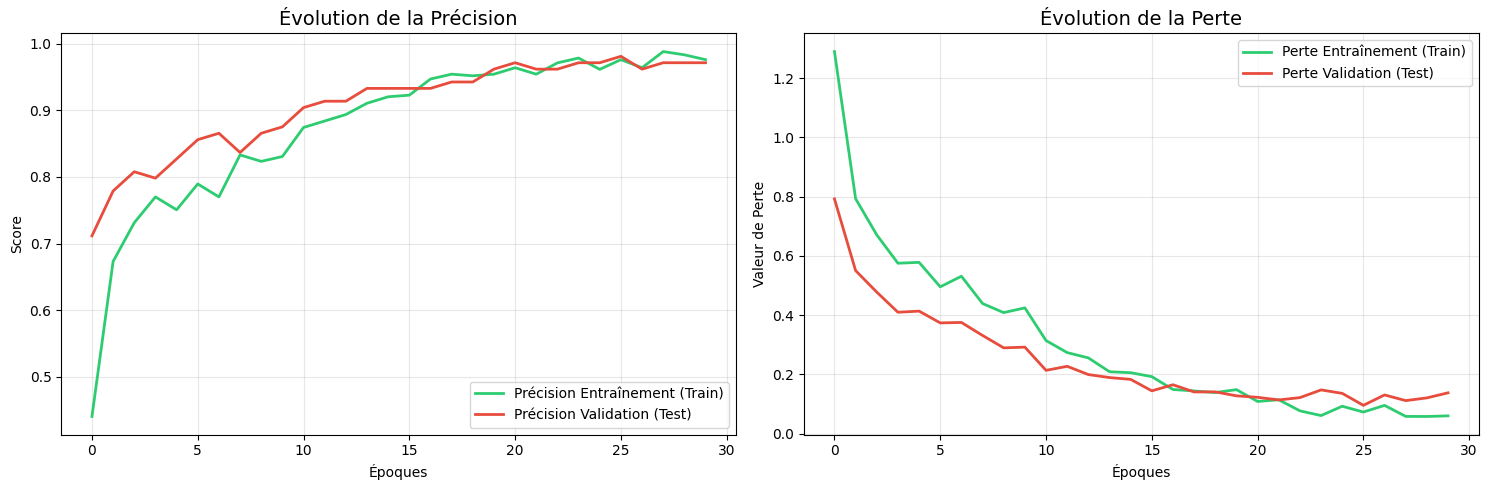

In [18]:
import matplotlib.pyplot as plt

# On vérifie que la variable 'history' existe bien
if 'history' in locals():
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(15, 5))

    # Graphique 1 : Précision
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Précision Entraînement (Train)', color='#2ecc71', lw=2)
    plt.plot(epochs_range, val_acc, label='Précision Validation (Test)', color='#e74c3c', lw=2)
    plt.title('Évolution de la Précision', fontsize=14)
    plt.xlabel('Époques')
    plt.ylabel('Score')
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)

    # Graphique 2 : Perte
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Perte Entraînement (Train)', color='#2ecc71', lw=2)
    plt.plot(epochs_range, val_loss, label='Perte Validation (Test)', color='#e74c3c', lw=2)
    plt.title('Évolution de la Perte', fontsize=14)
    plt.xlabel('Époques')
    plt.ylabel('Valeur de Perte')
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("Erreur : La variable 'history' n'a pas été trouvée. As-tu bien lancé l'entraînement ?")

Fichier : HFC_08.30.wav
Résultat IA : FOOD
Confiance : 96.60%


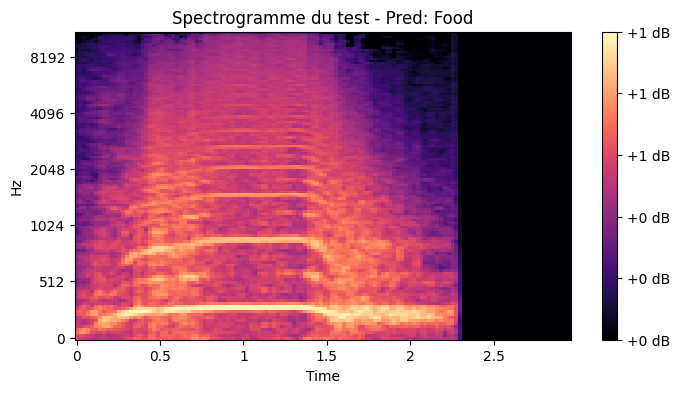

In [19]:
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
import os

def tester_IA_bovine(chemin_fichier):
    # 1. Chargement et Padding (3 secondes max)
    y, sr = librosa.load(chemin_fichier, duration=3.0)
    if len(y) < sr * 3:
        y = np.pad(y, (0, int(sr * 3) - len(y)))
    
    # 2. Transformation en Spectrogramme de Mel
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
    S_dB = librosa.power_to_db(S, ref=np.max)
    
    # 3. Forcer la dimension 128x128 (Padding/Cropping temporel)
    if S_dB.shape[1] > 128: 
        spec = S_dB[:, :128]
    else: 
        spec = np.pad(S_dB, ((0,0), (0, 128 - S_dB.shape[1])))
    
    # 4. Normalisation (0 à 1)
    spec_norm = (spec - spec.min()) / (spec.max() - spec.min() + 1e-6)
    
    # 5. Préparation pour le CNN (Batch, Hauteur, Largeur, Canal)
    entree_modele = spec_norm[np.newaxis, ..., np.newaxis]
    
    # 6. Prédiction
    predictions = model.predict(entree_modele, verbose=0)
    classe_idx = np.argmax(predictions[0])
    confiance = predictions[0][classe_idx] * 100
    nom_classe = le.inverse_transform([classe_idx])[0]
    
    # 7. Affichage Joli
    print("="*40)
    print(f"Fichier : {os.path.basename(chemin_fichier)}")
    print(f"Résultat IA : {nom_classe.upper()}")
    print(f"Confiance : {confiance:.2f}%")
    print("="*40)
    
    # 8. Affichage du spectrogramme testé
    plt.figure(figsize=(8, 4))
    librosa.display.specshow(spec_norm, sr=sr, x_axis='time', y_axis='mel')
    plt.title(f"Spectrogramme du test - Pred: {nom_classe}")
    plt.colorbar(format='%+2.0f dB')
    plt.show()

# --- ICI TU METS TON CHEMIN ---
fichier_a_tester = "/kaggle/input/datasets/mymy026/data-base-2/bovinetalk-main/Cattle sounds database (raw data)/COWS September 1/COW ID 2400/HFC/HFC_08.30.wav"

# Appel du test
tester_IA_bovine(fichier_a_tester)